# Imports

In [1]:
import numpy as np

import graphical_sampling as gs
import pandas as pd
import matplotlib.pyplot as plt

# Population

In [6]:
N = 1000
n = 20
rng = gs.random.rng()
coords = rng.rand_coord((N, 2))
# inclusions = np.array([0.2, 0.3, 0.1, 0.4, 0.3, 0.5, 0.4, 0.3, 0.4, 0.1])
inclusions = rng.equal_inclusions(n, N)
pop = gs.Population(coords, inclusions, n=n)

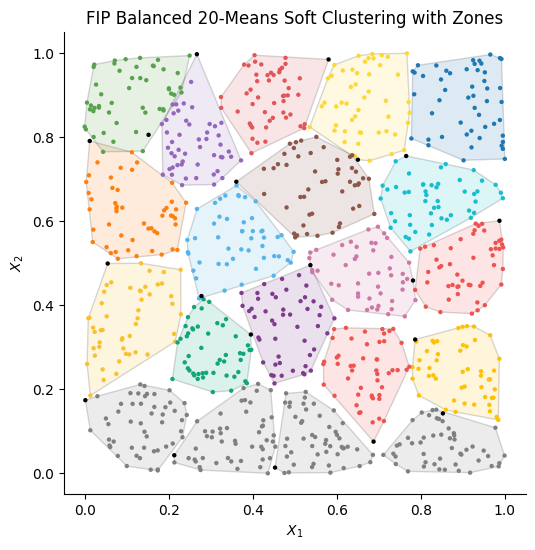

In [8]:
fbn = gs.clustering.IPBalancedOTNMeans(n, n_init=10)
fbn.fit(pop)
ax = fbn.plot(mode='soft', size_scale=500)
plt.savefig('/Users/mehdi/Desktop/new_clustering.pdf')

In [ ]:
design = gs.Design(pop, num_partitions=1, order=gs.Order.from_indices(pop))
design.plot()

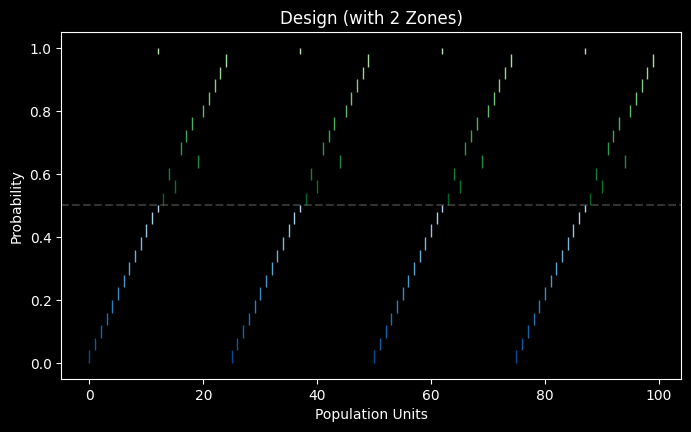

In [14]:
design = gs.Design(pop, num_partitions=2, order=gs.Order.from_indices(pop))
design.plot()

# Entropy

In [6]:
d = design.copy()
num_samples = []
entropy = []

total = 10000

step = 10000

def get_coef():
    return np.random.uniform(0.5, 0.8)

for i in range(total + 1):
    d.exchange(n_zones=2, pull_strategy='default', exchange_coef=0.75)
    # if i >= 1000:
    #     d.merge_identical()

    # if i % step == 0:
    #     d.merge_identical()
    #     samples, _ = d.all_samples_and_probs
    #     num_samples.append(samples.shape[0])
    #     entropy.append(d.entropy)
d.merge_identical()
samples, _ = d.all_samples_and_probs

In [7]:
# total = 25*33*49*97
total = 120
print(f'maximum number of samples: {total}')
print(f'number of samples in design: {samples.shape[0]} which is {100*samples.shape[0]/total:.2f}%')
print(f'maximum entropy: {d.maximum_entropy:.4f}')
print(f'design entropy: {d.entropy:.4f} which is {100*d.entropy/d.maximum_entropy:.2f}%')

maximum number of samples: 120
number of samples in design: 70 which is 58.33%
maximum entropy: 4.7875
design entropy: 3.8906 which is 81.27%


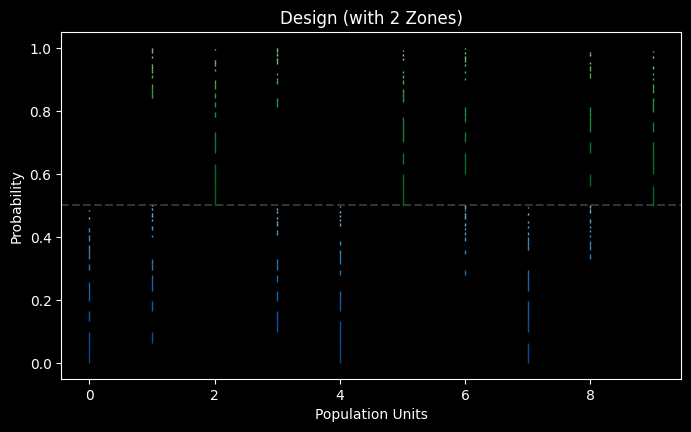

In [8]:
d.plot(save=True)

In [ ]:
plt.plot(np.arange(0, total+1, step), num_samples)
plt.axhline(y=(100*99*98*97)/24, color='r', linestyle='--', linewidth=2)
plt.ylabel('Number of Unique Samples in Design')
plt.xlabel('Number of Changes')
plt.savefig('/Users/mehdi/Desktop/n_samples.png', dpi=300)

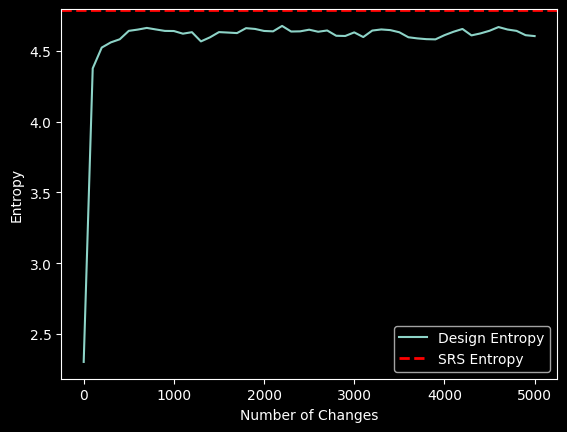

In [64]:
plt.plot(np.arange(0, total+1, step), entropy, label='Design Entropy')
plt.axhline(y=d.maximum_entropy, color='r', linestyle='--', linewidth=2, label='SRS Entropy')
plt.ylabel('Entropy')
plt.xlabel('Number of Changes')
plt.legend()
# plt.savefig('/Users/mehdi/Desktop/entropy.png', dpi=300)

In [190]:
-0.2*np.log(0.2), -(0.1*np.log(0.1)+0.1*np.log(0.1))

(np.float64(0.3218875824868201), np.float64(0.4605170185988091))

In [191]:
np.log(120)

np.float64(4.787491742782046)

In [8]:
from tqdm import tqdm

total = 50000
just_largest = 3000

def get_strategy(change):
    if change < just_largest:
        return 'combine'
    return 'combine'

best = []
coef = np.arange(0.01, 1.0, 0.01)

for c in tqdm(coef):
    d = design.copy()
    for i in range(total):
        d.exchange(n_zones=1, pull_strategy=get_strategy(i), exchange_coef=c)
        # if i >= just_largest:
        #     d.merge_identical()
    best.append(d.entropy)

100%|██████████| 99/99 [02:01<00:00,  1.23s/it]


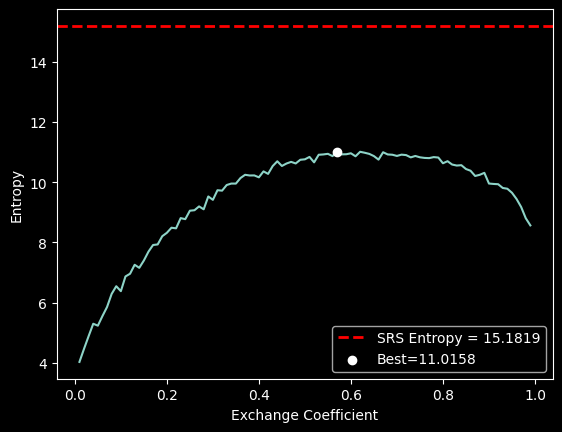

In [9]:
max_arg = np.array(best).argmax()
plt.plot(coef, best)
plt.axhline(y=d.maximum_entropy, color='r', linestyle='--', linewidth=2, label=f'SRS Entropy = {d.maximum_entropy:.4f}')
plt.scatter(coef[max_arg], best[max_arg], label=f'Best={best[max_arg]:.4f}', color='white', zorder=10)
plt.xlabel('Exchange Coefficient')
plt.ylabel('Entropy')
plt.legend()
plt.savefig('/Users/mehdi/Desktop/entropy_vs_coef.png', dpi=300)

# Moran

In [15]:
d = design.copy()
moran = []
moran_var = []

total = 100000
step = 1000

for i in range(total + 1):
    d.exchange(n_zones=2, pull_strategy='default', exchange_coef=0.75)

    if i % step == 0:
        d.merge_identical()
        moran.append(d.moran[0])
        moran_var.append(d.moran[1])

Text(0.5, 0, 'Number of Changes')

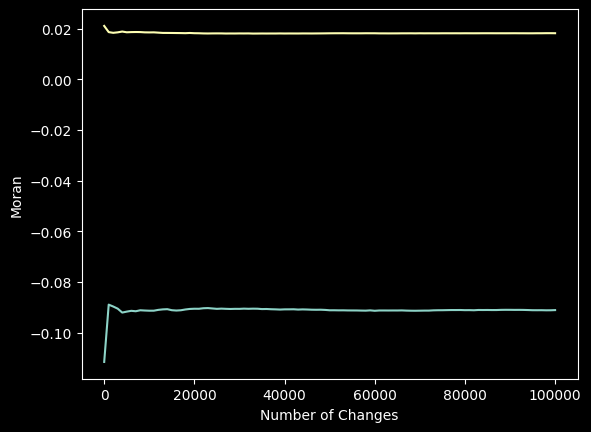

In [16]:
plt.plot(np.arange(0, total+1, step), moran, label='Moran')
plt.plot(np.arange(0, total+1, step), moran_var, label='Variance of Moran')
plt.ylabel('Moran')
plt.xlabel('Number of Changes')
# plt.savefig('/Users/mehdi/Desktop/n_samples.png', dpi=300)

In [22]:
indices = np.array([1, 2, 3, 4])
shares = np.array([0.5, 1.0, 0.8, 1.0])
num_splits = 4
indices = np.repeat(indices, num_splits)
shares = np.repeat(shares, num_splits) / num_splits
print(indices)
print(shares)

[1 1 1 1 2 2 2 2 3 3 3 3 4 4 4 4]
[0.125 0.125 0.125 0.125 0.25  0.25  0.25  0.25  0.2   0.2   0.2   0.2
 0.25  0.25  0.25  0.25 ]
